# ***KELOMPOK THE GACORS***
---
Notebook ini disusun agar bisa langsung dijalankan secara berurutan untuk menghasilkan file submission kompetisi.

## ***Introduction***
kompetisi ini bertujuan untuk mengembangkan model computer vision berbasis citra (image-based) yang mampu membedakan antara wajah asli dan berbagai bentuk serangan spoofing. Dataset yang digunakan terdiri dari kumpulan foto wajah dengan variasi kondisi pencahayaan, sudut pengambilan, serta jenis serangan, sehingga mencerminkan skenario dunia nyata dan menuntut model yang robust serta memiliki kemampuan generalisasi yang baik.

## ***Approach***
Pendekatan yang digunakan di notebook ini:
- Menyiapkan struktur direktori dan memvalidasi path dataset.
- Membersihkan data train dengan memindahkan gambar yang salah folder berdasarkan file JSON.
- Menghapus duplikasi gambar dengan hash cepat, lalu membuat split train dan validasi yang stratified.
- Melatih model backbone DINOv3 ConvNeXt dengan head klasifikasi dan loss yang lebih robust untuk imbalance.
- Melakukan inference pada test dengan test-time augmentation sederhana dan menyimpan submission.

Kami menggunakan DINOv3 (ConvNeXt-Large) sebagai *backbone* pengekstraksi fitur. Fitur tersebut kemudian dilewatkan ke sebuah *Adapter Layer* dengan *residual connection* sebelum masuk ke *Classifier Head*. Pada tahap *inference*, kami menerapkan strategi *Test-Time Augmentation* (TTA) yang ekstensif dikombinasikan dengan *Temperature Scaling* untuk menstabilkan prediksi akhir.

```text
DINOv3 ConvNeXt-Large (Backbone)
   |
   +-- Raw Image -> 1536-dim embeddings
   |
   v
Global Average Pooling (mean over dim=1)
   |
   +-- Custom Adapter 
   |      (Linear -> LayerNorm -> GELU -> Dropout(0.1) -> Linear)
   |      |
   |      v
   +<-- Residual Connection ( x + 0.5 * adapter(x) )
   |
   v
Classifier Head 
   (Linear 512 -> LayerNorm -> GELU -> Dropout(0.3) -> Linear 6 classes)
   |
   v
Raw Logits (6 classes: mannequin, mask, printed, screen, unknown, real)
   |
   v
Test-Time Augmentation (TTA) Ensemble
   |
   +-- 5 Resolusi / Scales (224, 256, 288, 320, 384)
   |      |
   |      +-- 4 Augmentasi Spasial (Original, H-Flip, V-Flip, Rotate 90)
   |      |
   |      v
   |   Total 20 Forward Passes per gambar
   |
   v
Temperature Scaling (Logits / T=1.0) -> Softmax
   |
   v
Averaged Probabilities -> Argmax -> submission.csv
```

## ***Referensi***
- Paper referensi model: https://arxiv.org/pdf/2508.10104

## ***Table of Contents***
- [Import Dependencies](#import-dependencies)
- [Prepare Data](#prepare-data)
- [Clean Label Folder](#clean-label-folder)
- [Configuration](#configuration)
- [Dedup dan Split](#dedup-split)
- [Preprocessing dan Augmentation](#preprocessing-augmentation)
- [Model dan Metric](#model-metric)
- [Training](#training)
- [Evaluation](#evaluation)
- [Inference dan Submission](#inference-submission)

<a id="import-dependencies"></a>
# ***IMPORT DEPENDENCIES***
---

In [ ]:
!pip -q install evaluate gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
from collections import Counter
from io import BytesIO

import contextlib
import gc
import hashlib
import json
import math
import os
import random
import shutil
import zipfile

import cv2
import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T

from PIL import Image, ImageEnhance
from PIL import Image as PILImage
from tqdm.auto import tqdm

from datasets import load_dataset, load_from_disk
from huggingface_hub import login

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
 )

from torchvision.transforms import (
    ColorJitter,
    Compose,
    GaussianBlur,
    Normalize,
    RandomHorizontalFlip,
    Resize,
    ToTensor,
 )

from transformers import (
    AutoImageProcessor,
    AutoModel,
    AutoModelForImageClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
 )

from transformers.utils.notebook import NotebookProgressCallback

from warnings import filterwarnings
filterwarnings('ignore')

<a id="prepare-data"></a>
## ***Prepare data***

In [ ]:
BASE_WORKDIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
DATA_WORKDIR = BASE_WORKDIR / 'data'
DATA_WORKDIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = BASE_WORKDIR / 'best_model.pt'

def resolve_competition_dir() -> Path:
    kaggle_candidates = [
        Path('/kaggle/input/competitions/data-analytics-competition-dac-find-it-2026'),
        Path('/kaggle/input/data-analytics-competition-dac-find-it-2026'),
    ]
    for c in kaggle_candidates:
        if (c / 'train').exists() and (c / 'test').exists():
            return c

    start = Path.cwd()
    for p in [start, *start.parents]:
        if (p / 'train').exists() and (p / 'test').exists():
            return p

    raise FileNotFoundError(
        'Folder dataset tidak ditemukan. Pastikan ada struktur: <root>/train dan <root>/test.'
    )

COMPETITION_DATA_DIR = resolve_competition_dir()
TRAIN_DIR = COMPETITION_DATA_DIR / 'train'
TEST_DIR = COMPETITION_DATA_DIR / 'test'
SAMPLE_SUB_PATH = COMPETITION_DATA_DIR / 'samplesubmission.csv'

CLEAN_TRAIN_DIR = DATA_WORKDIR / 'train_clean'
JSON_DIR = DATA_WORKDIR / 'misplaced_images.json'

print('COMPETITION_DATA_DIR:', COMPETITION_DATA_DIR)

Download data yang dibutuhkan:
- file JSON yang berisi file yang dipindah (Disesuaikan gambar dengan folder label yang sesuai)
- Model final untuk inference

In [ ]:
# Download file pendukung bila belum ada
if not JSON_DIR.exists():
    !gdown --fuzzy https://drive.google.com/file/d/1N5lO6NmceyZHcswxgHr07kqVboYbVuri/view?usp=sharing -O {JSON_DIR}
else:
    print('Skip download (JSON sudah ada):', JSON_DIR)

if not BEST_MODEL_PATH.exists():
    !gdown --fuzzy https://drive.google.com/file/d/1dJTIrPEqJBJfIQF_EzrDQHs15bdAq7J9/view?usp=sharing -O {BEST_MODEL_PATH}
else:
    print('Skip download (model sudah ada):', BEST_MODEL_PATH)

Downloading...
From: https://drive.google.com/uc?id=1N5lO6NmceyZHcswxgHr07kqVboYbVuri
To: /kaggle/working/data/misplaced_images.json
100%|██████████████████████████████████████| 82.6k/82.6k [00:00<00:00, 64.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1dJTIrPEqJBJfIQF_EzrDQHs15bdAq7J9
From (redirected): https://drive.google.com/uc?id=1dJTIrPEqJBJfIQF_EzrDQHs15bdAq7J9&confirm=t&uuid=2a55846e-01a2-49e4-aa9b-953169d5ff50
To: /kaggle/working/best_model.pt
100%|████████████████████████████████████████| 807M/807M [00:08<00:00, 90.5MB/s]


<a id="clean-label-folder"></a>
## ***Move Image to Correct Label Folder***
Bagian ini melakukan cleaning pada data train. Kita menyalin dataset train ke folder kerja, lalu memindahkan gambar yang berada di folder label yang salah berdasarkan file JSON. Hasil akhirnya adalah dataset train yang lebih konsisten untuk proses training.

In [5]:
def prepare_and_clean_dataset(json_file, input_folder, clean_folder):
    input_dir = Path(input_folder)
    clean_dir = Path(clean_folder)
    json_path = Path(json_file)
    
    if not json_path.exists():
        print("Error: File JSON tidak ditemukan.")
        return

    if not clean_dir.exists():
        shutil.copytree(input_dir, clean_dir)
        print("Proses copy seluruh dataset selesai.")
    
    with open(json_path, 'r') as f:
        misplaced_files = json.load(f)

    berhasil = 0
    gagal = 0

    for item in misplaced_files:
        src = clean_dir / item["target_folder"] / item["file_name"]
        dst = clean_dir / item["source_folder"] / item["file_name"]
        
        dst.parent.mkdir(parents=True, exist_ok=True)
        
        try:
            if src.exists():
                shutil.move(str(src), str(dst))
                berhasil += 1
            else:
                print(f"File tidak ditemukan: {src.name}")
                gagal += 1
        except Exception as e:
            print(f"Gagal memindah {item['file_name']}: {e}")
            gagal += 1

    print(f"Proses cleaning selesai. Berhasil: {berhasil}, Gagal: {gagal}")
    
prepare_and_clean_dataset(JSON_DIR, TRAIN_DIR, CLEAN_TRAIN_DIR)

Proses copy seluruh dataset selesai.
Proses cleaning selesai. Berhasil: 219, Gagal: 0


<a id="configuration"></a>
## ***Configuration***
Konfigurasi utama yang dipakai sepanjang notebook: seed, lokasi dataset train dan test, checkpoint model, serta lokasi output.

In [ ]:
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

DATA_TRAIN_FULL_DIR = CLEAN_TRAIN_DIR
DATA_TEST_FULL_DIR = TEST_DIR

MODEL_CHECKPOINT = 'facebook/dinov3-convnext-large-pretrain-lvd1689m'
OUTPUT_DIR = BASE_WORKDIR / 'outputs/dinov3_convnext_large'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [DATA_TRAIN_FULL_DIR, DATA_TEST_FULL_DIR, SAMPLE_SUB_PATH]
missing = [p for p in required_paths if not Path(p).exists()]
if missing:
    raise FileNotFoundError('Path wajib tidak ditemukan: ' + ', '.join(str(p) for p in missing))

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)
print('TRAIN DIR:', DATA_TRAIN_FULL_DIR)
print('TEST  DIR:', DATA_TEST_FULL_DIR)

DEVICE: cuda
DATA_TRAIN_FULL_DIR: /kaggle/working/data/train_clean
DATA_TEST_FULL_DIR: /kaggle/input/competitions/data-analytics-competition-dac-find-it-2026/test
SAMPLE_SUB_PATH: /kaggle/input/competitions/data-analytics-competition-dac-find-it-2026/samplesubmission.csv


<a id="dedup-split"></a>
# ***LOAD DATASET & SPLIT VALIDASI***
---
Di tahap ini kita memuat dataset train, menghapus duplikasi, lalu membuat split train dan validasi secara stratified agar distribusi label tetap stabil.

## ***Remove Duplicate***
Untuk mengurangi data leakage dan bias, kita menghapus gambar yang identik (exact duplicate) menggunakan hash cepat dari versi grayscale yang di-resize. Setelah itu dataset dibagi menjadi train dan validasi secara stratified.

In [ ]:
DEDUP_SAVE_PATH = BASE_WORKDIR / 'deduped_split'
DEDUP_META_PATH = BASE_WORKDIR / 'dedup_meta.json'

def fast_image_hash(img):
    img = img.resize((64, 64)).convert('L')
    return hashlib.md5(img.tobytes()).hexdigest()

if DEDUP_SAVE_PATH.exists() and DEDUP_META_PATH.exists():
    print('Cache ditemukan, loading dari disk')
    split = load_from_disk(str(DEDUP_SAVE_PATH))
    train_ds = split['train']
    valid_ds = split['test']

    with open(DEDUP_META_PATH) as f:
        meta = json.load(f)

    print(f"train={meta['n_train']}, valid={meta['n_valid']}, removed={meta['n_removed_exact']}")
else:
    print('Menjalankan dedup (full image)')
    raw_full = load_dataset('imagefolder', data_dir=str(DATA_TRAIN_FULL_DIR))
    full_ds = raw_full['train']

    hash_seen = set()
    keep_indices = []

    for idx in tqdm(range(len(full_ds)), desc='Dedup'):
        h = fast_image_hash(full_ds[idx]['image'])
        if h not in hash_seen:
            hash_seen.add(h)
            keep_indices.append(idx)

    n_removed = len(full_ds) - len(keep_indices)
    print(f"Duplikat dihapus: {n_removed} dari {len(full_ds)}")

    deduped_full = full_ds.select(keep_indices)
    split = deduped_full.train_test_split(
        test_size=0.2,
        seed=SEED,
        stratify_by_column='label',
    )
    train_ds = split['train']
    valid_ds = split['test']

    DEDUP_SAVE_PATH.mkdir(parents=True, exist_ok=True)
    split.save_to_disk(str(DEDUP_SAVE_PATH))

    meta = {
        'n_train': len(train_ds),
        'n_valid': len(valid_ds),
        'n_removed_exact': n_removed,
    }
    with open(DEDUP_META_PATH, 'w') as f:
        json.dump(meta, f, indent=2)

    print('Cache disimpan ke:', DEDUP_SAVE_PATH)

⚙️ Running FAST dedup pipeline (FULL IMAGE)...


Resolving data files:   0%|          | 0/1652 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Fast dedup (full): 100%|██████████| 1652/1652 [01:07<00:00, 24.60it/s] 


🧹 Duplikat dihapus: 178 dari 1652 total


Saving the dataset (0/2 shards):   0%|          | 0/1179 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/295 [00:00<?, ? examples/s]

✓ Disimpan → /kaggle/working/deduped_split
  train=1179, valid=295


## ***Label Mapping***
Kita ambil nama kelas dari dataset, lalu membentuk mapping `id2label` dan `label2id`. Mapping ini dipakai konsisten saat training, evaluasi, dan saat membuat file submission.

In [8]:
# Label
label_names = train_ds.features['label'].names

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in id2label.items()}

print('Jumlah train :', len(train_ds))
print('Jumlah valid :', len(valid_ds))
print('Label       :', label_names)

print(train_ds[0].keys())

Jumlah train : 1179
Jumlah valid : 295
Label       : ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']
dict_keys(['image', 'label'])


In [9]:
print("id2label:")
print(id2label)
print(Counter(train_ds['label']))

id2label:
{0: 'fake_mannequin', 1: 'fake_mask', 2: 'fake_printed', 3: 'fake_screen', 4: 'fake_unknown', 5: 'realperson'}
Counter({5: 324, 4: 264, 1: 209, 3: 155, 0: 142, 2: 85})


## ***Label Distribution***

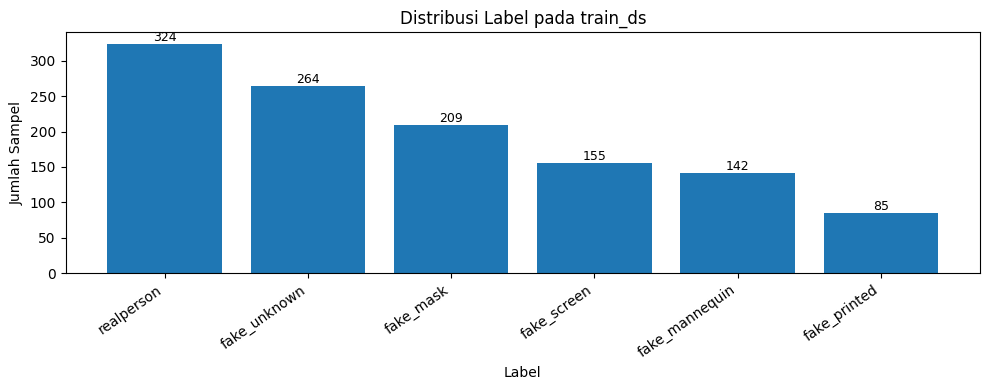

In [10]:
label_counts = pd.Series(train_ds['label']).value_counts().sort_values(ascending=False)
label_names_ordered = [id2label[i] for i in label_counts.index]

plt.figure(figsize=(10, 4))
bars = plt.bar(label_names_ordered, label_counts.values)
plt.title('Distribusi Label pada train_ds')
plt.xlabel('Label')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=35, ha='right')

for bar, value in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## ***Contoh Gambar***

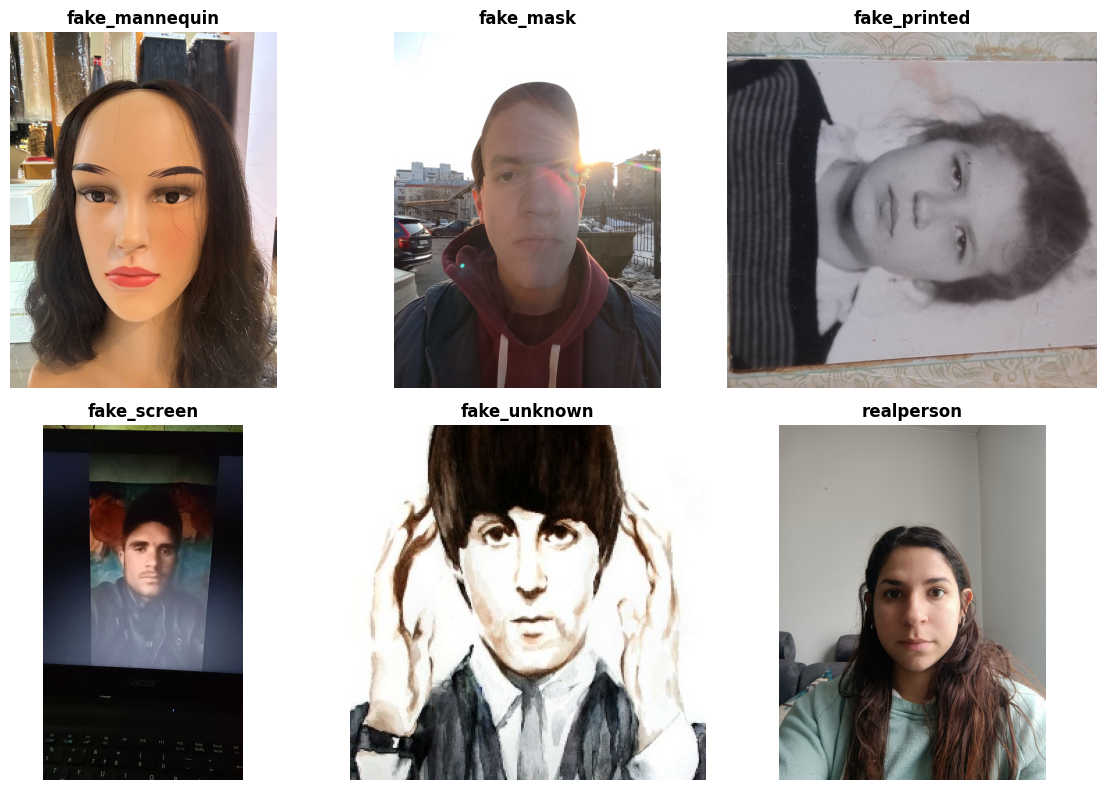

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(label_names) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten() if len(label_names) > 1 else [axes]

for label_idx, label_name in enumerate(label_names):
    label_indices = [i for i, x in enumerate(train_ds['label']) if x == label_idx]
    if not label_indices:
        axes[label_idx].axis('off')
        continue

    sample_idx = label_indices[0]
    sample = train_ds[sample_idx]
    img = sample['image'].convert('RGB')

    axes[label_idx].imshow(img)
    axes[label_idx].set_title(label_name, fontsize=12, fontweight='bold')
    axes[label_idx].axis('off')

for idx in range(len(label_names), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

<a id="preprocessing-augmentation"></a>
# ***PREPROCESSING & AUGMENTATION***
---
Di tahap ini kita menyiapkan image processor dari checkpoint, mendefinisikan transform augmentasi untuk train dan transform minimal untuk validasi.

In [ ]:
HF_TOKEN = os.environ.get("HF_TOKEN", "")  # Set via environment variable or Kaggle Secret

if HF_TOKEN:
    login(HF_TOKEN)
else:
    print('HF_TOKEN tidak ditemukan. Login dilewati.')

In [13]:
processor = AutoImageProcessor.from_pretrained(MODEL_CHECKPOINT)
processor

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

DINOv3ViTImageProcessorFast {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

## ***Fungsi untuk Transform***
Kumpulan fungsi di bawah adalah komponen augmentasi kustom yang dipakai untuk membuat data latih lebih beragam. Ringkasnya:
- `RandomSharpening`: mempertajam gambar secara acak agar model lebih tahan terhadap variasi ketajaman.
- `RandomJPEGCompression`: mensimulasikan artefak kompresi kamera atau aplikasi chat.
- `RandomLowResolution`: menurunkan resolusi lalu menaikkan kembali untuk mensimulasikan blur atau gambar berkualitas rendah.
- `RandomPixelation`: mensimulasikan efek pixelated pada gambar.
- `AddGaussianNoise`: menambah noise kecil pada tensor untuk meningkatkan robustness.
- `MoirePattern`: menambahkan pola sinus ringan untuk mensimulasikan efek moire dari layar atau cetakan.

Semua transform ini hanya aktif pada train, sedangkan validasi memakai transform minimal agar metrik lebih representatif.

In [ ]:
size_cfg = processor.size
image_size = size_cfg.get('shortest_edge') or size_cfg.get('height') or 224

mean = processor.image_mean
std = processor.image_std

class AddGaussianNoise:
    def __init__(self, std=0.005, p=0.03):
        self.std = std
        self.p = p
    def __call__(self, tensor):
        if random.random() < self.p:
            return tensor + torch.randn_like(tensor) * self.std
        return tensor

class RandomJPEGCompression:
    def __init__(self, quality_range=(70, 95), p=0.5):
        self.quality_range = quality_range
        self.p = p
    def __call__(self, img):
        if random.random() > self.p:
            return img
        buf = BytesIO()
        quality = random.randint(*self.quality_range)
        img.save(buf, format='JPEG', quality=quality)
        buf.seek(0)
        return Image.open(buf).convert('RGB')

class RandomLowResolution:
    def __init__(self, scale_range=(0.6, 0.9), p=0.5):
        self.scale_range = scale_range
        self.p = p
    def __call__(self, img):
        if random.random() > self.p:
            return img
        w, h = img.size
        scale = random.uniform(*self.scale_range)
        nw, nh = int(w * scale), int(h * scale)
        img = img.resize((nw, nh), Image.BILINEAR)
        return img.resize((w, h), Image.BILINEAR)

class RandomPixelation:
    def __init__(self, scale_range=(0.3, 0.5), p=0.5):
        self.scale_range = scale_range
        self.p = p
    def __call__(self, img):
        if random.random() > self.p:
            return img
        w, h = img.size
        scale = random.uniform(*self.scale_range)
        sw, sh = int(w * scale), int(h * scale)
        img = img.resize((sw, sh), Image.NEAREST)
        return img.resize((w, h), Image.NEAREST)

class MoirePattern:
    def __init__(self, p=0.15):
        self.p = p
    def __call__(self, tensor):
        if random.random() > self.p:
            return tensor
        freq = random.uniform(10, 30)
        h = tensor.shape[-2]
        y = torch.arange(h, dtype=torch.float32) / h
        moire = (torch.sin(2 * math.pi * freq * y) * 0.04).view(-1, 1)
        return (tensor + moire).clamp(0, 1)

class RandomSharpening:
    def __init__(self, p=0.3):
        self.p = p
    def __call__(self, img):
        if random.random() > self.p:
            return img
        factor = random.uniform(1.5, 3.0)
        return ImageEnhance.Sharpness(img).enhance(factor)

## ***Transform Augmentation***
Pipeline augmentasi train menggabungkan resize, beberapa augmentasi berbasis kualitas gambar, dan augmentasi geometrik ringan (flip, rotasi kecil). Setelah itu tensor dinormalisasi memakai mean dan std dari processor checkpoint agar konsisten dengan pretraining backbone.

In [ ]:
train_tfms = Compose([
    Resize((image_size, image_size)),
    RandomSharpening(p=0.3),
    RandomJPEGCompression(quality_range=(70, 95), p=0.5),
    RandomLowResolution(scale_range=(0.6, 0.9), p=0.5),
    RandomPixelation(scale_range=(0.3, 0.5), p=0.25),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=5),
    T.RandomApply([GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.1),
    T.RandomGrayscale(p=0.02),
    ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    ToTensor(),
    AddGaussianNoise(std=0.005, p=0.03),
    MoirePattern(p=0.08),
    Normalize(mean=mean, std=std),
])

valid_tfms = Compose([
    Resize((image_size, image_size)),
    ToTensor(),
    Normalize(mean=mean, std=std),
])

In [ ]:
print('mean:', processor.image_mean)
print('std :', processor.image_std)
print('mean (tfms):', mean)
print('std  (tfms):', std)

mean: [0.485, 0.456, 0.406]
std: [0.229, 0.224, 0.225]
mean dari tfms: [0.485, 0.456, 0.406]
std dari tfms: [0.229, 0.224, 0.225]


## ***Preprocessing***

In [ ]:
def preprocess_train(batch):
    pixel_values = []
    for img in batch['image']:
        img = img.convert('RGB')
        pixel_values.append(train_tfms(img))
    batch['pixel_values'] = pixel_values
    return batch

def preprocess_valid(batch):
    pixel_values = []
    for img in batch['image']:
        img = img.convert('RGB')
        pixel_values.append(valid_tfms(img))
    batch['pixel_values'] = pixel_values
    return batch

def collate_fn(examples):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in examples]),
        'labels': torch.tensor([x['label'] for x in examples], dtype=torch.long),
    }

<a id="model-metric"></a>
# ***MODEL, TRAINER, METRIC***
---
Bagian ini mendefinisikan arsitektur model yang dipakai (backbone + head), fungsi loss, serta metrik evaluasi yang akan dilaporkan selama training.

## ***Custom Model***

In [ ]:
counts = Counter(train_ds['label'])
total = sum(counts.values())
class_weights = torch.tensor(
    [(total / counts[i]) ** 0.4 for i in range(len(counts))],
    dtype=torch.float,
 )
print('Class weights:', class_weights)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.register_buffer('weight', weight)

    def forward(self, logits, targets):
        weight = self.weight
        if weight is not None:
            weight = weight.to(logits.device)
        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=weight,
            label_smoothing=self.label_smoothing,
            reduction='none',
        )
        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean()

class DINOv3ConvNeXtClassifier(nn.Module):
    def __init__(self, backbone, num_classes, id2label=None, label2id=None):
        super().__init__()
        self.backbone = backbone
        hidden_dim = 1536

        self.adapter = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

        self.loss_fn = FocalLoss(
            gamma=2.0,
            weight=class_weights,
            label_smoothing=0.05,
        )
        self.id2label = id2label
        self.label2id = label2id

    def forward(self, pixel_values, labels=None):
        outputs = self.backbone(pixel_values=pixel_values)
        x = outputs.last_hidden_state.mean(dim=1)
        x = x + 0.5 * self.adapter(x)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)

        return {'loss': loss, 'logits': logits}

Class weights: tensor([2.3318, 1.9978, 2.8631, 2.2515, 1.8195, 1.6764])


config.json:   0%|          | 0.00/449 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/785M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

<a id="training"></a>
# ***TRAINING***
---
Training dilakukan menggunakan `Trainer` dari Transformers. Output utamanya adalah model terbaik (berdasarkan macro F1) dan metrik evaluasi pada validation split.

## ***Setup Trainer***
Langkah ini menyiapkan metrik, dataset transform, model, dan `TrainingArguments`. Setelah training selesai, notebook akan menyimpan model terbaik dan menyiapkan variabel untuk evaluasi (confusion matrix dan contoh misclassified).

In [ ]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

In [ ]:
acc_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = acc_metric.compute(predictions=preds, references=labels)['accuracy']
    macro_f1 = f1_metric.compute(predictions=preds, references=labels, average='macro')['f1']
    return {'accuracy': acc, 'macro_f1': macro_f1}

OUTPUT_PATH = OUTPUT_DIR / 'single_split'
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
best_model_path = OUTPUT_PATH / 'best_model.pth'

train_ds_split = train_ds.with_transform(preprocess_train)
valid_ds_split = valid_ds.with_transform(preprocess_valid)

backbone = AutoModel.from_pretrained(MODEL_CHECKPOINT)
model = DINOv3ConvNeXtClassifier(
    backbone,
    num_classes=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

args = TrainingArguments(
    output_dir=str(OUTPUT_PATH),
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=20,
    learning_rate=1e-5,
    lr_scheduler_type='cosine',
    warmup_ratio=0.1,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=1,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.02,
    max_grad_norm=1.0,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    remove_unused_columns=False,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to='none',
    dataloader_num_workers=0,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds_split,
    eval_dataset=valid_ds_split,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

preds_output = trainer.predict(valid_ds_split)
all_preds = np.argmax(preds_output.predictions, axis=-1)
true_labels = preds_output.label_ids

print('\nClassification Report')
print(
    classification_report(
        true_labels,
        all_preds,
        target_names=[id2label[i] for i in range(len(label_names))],
        digits=4,
    )
 )

torch.save(trainer.model.state_dict(), best_model_path)
TRAINED_MODEL_PATH = best_model_path
print('Saved model to:', best_model_path)

del trainer
torch.cuda.empty_cache()
gc.collect()


========== TRAIN-VALID ==========


Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,3.642627,1.688649,0.793220,0.737960
2,2.682592,0.418368,0.952542,0.947166
3,0.730674,0.362295,0.955932,0.951612
4,0.298180,0.328636,0.952542,0.953104
5,0.193166,0.321329,0.962712,0.959718
6,0.145457,0.259700,0.962712,0.961199
7,0.122271,0.284297,0.966102,0.961276
8,0.107732,0.318408,0.966102,0.961276
9,0.096065,0.309966,0.962712,0.957787
10,0.100463,0.310959,0.962712,0.957787



📊 Classification Report


                precision    recall  f1-score   support

fake_mannequin     0.9714    0.9444    0.9577        36
     fake_mask     0.9808    0.9808    0.9808        52
  fake_printed     1.0000    0.8571    0.9231        21
   fake_screen     0.9286    1.0000    0.9630        39
  fake_unknown     0.9851    1.0000    0.9925        66
    realperson     0.9506    0.9506    0.9506        81

      accuracy                         0.9661       295
     macro avg     0.9694    0.9555    0.9613       295
  weighted avg     0.9668    0.9661    0.9658       295

Saved model to: /kaggle/working/outputs/dinov3_convnext_large/single_split/best_model.pth


1663

<a id="evaluation"></a>

# ***EVALUATION***
---
Bagian ini memvisualisasikan performa model pada validation split menggunakan confusion matrix dan beberapa contoh gambar yang salah diprediksi.

## ***Heatmap***
Confusion matrix membantu melihat label mana yang paling sering tertukar. Ini dihitung dari `true_labels` dan `all_preds` yang sudah dibuat pada akhir proses training.

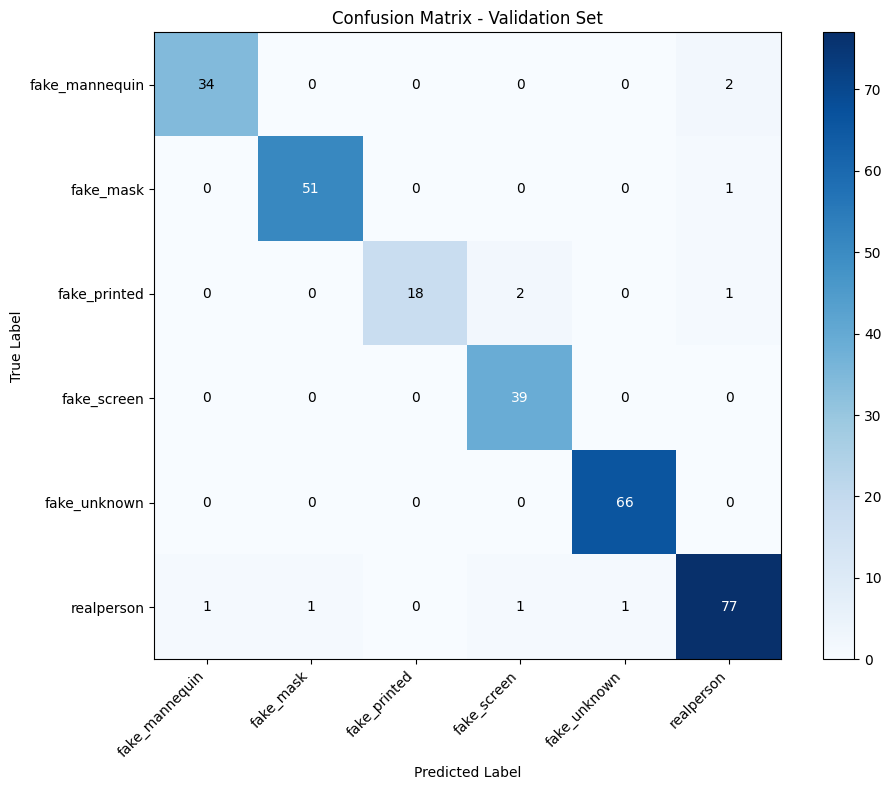

In [25]:
cm = confusion_matrix(true_labels, all_preds)

plt.figure(figsize=(10, 8))
im = plt.imshow(cm, cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Validation Set')
plt.colorbar(im)

plt.xticks(range(len(label_names)), label_names, rotation=45, ha='right')
plt.yticks(range(len(label_names)), label_names)

for i in range(len(label_names)):
    for j in range(len(label_names)):
        text = plt.text(j, i, cm[i, j], ha='center', va='center',
                       color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=10)

plt.tight_layout()
plt.show()

## ***Visualization - Misclassified Examples***
Visualisasi ini menampilkan beberapa contoh gambar di validation yang salah diprediksi, beserta label asli dan label prediksi.

Total errors: 10 / 295 (3.39%)


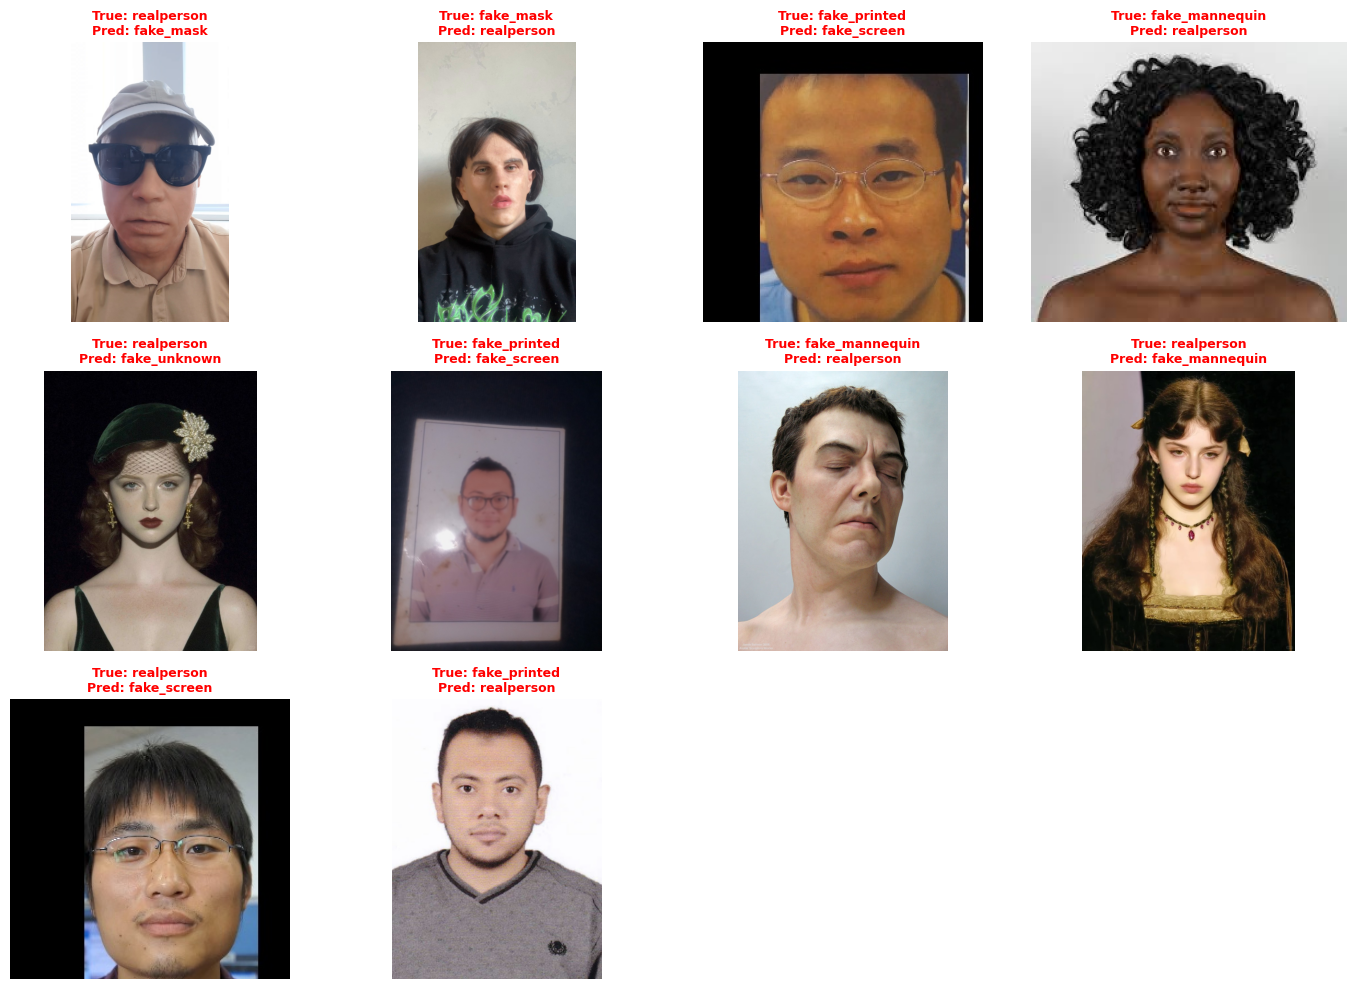

In [ ]:
wrong_indices = [i for i in range(len(true_labels)) if true_labels[i] != all_preds[i]]
print(
    f'Total errors: {len(wrong_indices)} / {len(true_labels)} '
    f'({100*len(wrong_indices)/len(true_labels):.2f}%)'
 )

n_show = min(12, len(wrong_indices))
random_wrong = random.sample(wrong_indices, n_show)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for idx, plot_idx in enumerate(random_wrong):
    sample = valid_ds[plot_idx]
    img = sample['image'].convert('RGB')

    true_label = label_names[true_labels[plot_idx]]
    pred_label = label_names[all_preds[plot_idx]]

    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(
        f'True: {true_label}\nPred: {pred_label}',
        fontsize=9,
        color='red',
        fontweight='bold',
    )

for idx in range(n_show, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

<a id="inference-submission"></a>
# ***INFERENCE, TEST, SUBMISSION***
---
Bagian ini memuat model terbaik, melakukan prediksi untuk seluruh gambar pada folder test, lalu menyimpan file `submission.csv` sesuai format `samplesubmission.csv`.

In [ ]:
candidate_paths = []
if 'TRAINED_MODEL_PATH' in globals():
    candidate_paths.append(Path(TRAINED_MODEL_PATH))
candidate_paths.append(BEST_MODEL_PATH)
candidate_paths.append(BASE_WORKDIR / 'best_model.pt')

model_path = next((p for p in candidate_paths if p.exists()), None)
if model_path is None:
    raise FileNotFoundError('Model tidak ditemukan. Jalankan training atau pastikan file model sudah terdownload.')
print('Using model:', model_path)

backbone = AutoModel.from_pretrained(MODEL_CHECKPOINT)
model = DINOv3ConvNeXtClassifier(
    backbone,
    num_classes=len(label_names),
    id2label=id2label,
    label2id=label2id,
 )

state_dict = torch.load(model_path, map_location='cpu')
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()
print('Loaded model')

submission = pd.read_csv(SAMPLE_SUB_PATH)
valid_exts = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']

def find_image(image_id, base_dir: Path):
    for ext in valid_exts:
        p = base_dir / f'{image_id}{ext}'
        if p.exists():
            return str(p)
    return None

image_paths_full = submission['id'].map(lambda x: find_image(x, Path(DATA_TEST_FULL_DIR)))
missing = image_paths_full.isna().sum()
print('Missing images:', missing)

scales = [224, 256, 288, 320, 384]
TEMPERATURE = 1.0
batch_size = 16

Using model: /kaggle/working/best_model.pt


Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

✅ Loaded single model
Missing images: 0


## ***Inference Loop***
Loop ini membaca gambar test secara batch, lalu menghitung probabilitas prediksi dengan beberapa skala input dan flip horizontal. Probabilitas dari beberapa augmentasi dirata-ratakan sebelum mengambil label final.

In [ ]:
pred_labels = []
all_probs = []
print(f'Single model inference | scales={scales} | T={TEMPERATURE}')

autocast_ctx = torch.cuda.amp.autocast if DEVICE == 'cuda' else contextlib.nullcontext

for i in tqdm(range(0, len(submission), batch_size)):
    batch_full = image_paths_full.iloc[i:i + batch_size].tolist()
    imgs_full = [
        PILImage.open(p).convert('RGB') if p else PILImage.new('RGB', (224, 224))
        for p in batch_full
    ]

    probs_tta = None
    count = 0

    with torch.no_grad(), autocast_ctx():
        for size in scales:
            resized = [img.resize((size, size)) for img in imgs_full]

            inp = processor(images=resized, return_tensors='pt').to(DEVICE)
            probs = torch.softmax(model(**inp)['logits'] / TEMPERATURE, dim=-1)
            probs_tta = probs if probs_tta is None else (probs_tta + probs)
            count += 1

            flipped_h = [img.transpose(PILImage.FLIP_LEFT_RIGHT) for img in resized]
            inp_fh = processor(images=flipped_h, return_tensors='pt').to(DEVICE)
            probs_fh = torch.softmax(model(**inp_fh)['logits'] / TEMPERATURE, dim=-1)
            probs_tta = probs_tta + probs_fh
            count += 1

        probs_tta = probs_tta / count

    all_probs.append(probs_tta.cpu())
    preds = torch.argmax(probs_tta, dim=-1).cpu().numpy().tolist()
    pred_labels.extend([id2label[p] for p in preds])

all_probs = torch.cat(all_probs, dim=0)
confidence = all_probs.max(dim=-1).values

print('Inference selesai:', len(pred_labels), 'samples')
print('Confidence mean:', float(confidence.mean()))
print('Confidence min :', float(confidence.min()))

pred_dist = Counter(pred_labels)
print('\nDistribusi prediksi:')
for name, count in sorted(pred_dist.items()):
    print(f'  {name:20s}: {count}')

✅ Single model inference | scales=[224, 256, 288, 320, 384] | T=1.0


100%|██████████| 26/26 [01:38<00:00,  3.77s/it]


Inference selesai: 404 samples
Confidence mean : 0.9336
Confidence min  : 0.2903

Distribusi prediksi:
  fake_mannequin      : 50
  fake_mask           : 69
  fake_printed        : 60
  fake_screen         : 72
  fake_unknown        : 49
  realperson          : 104


In [ ]:
submission['label'] = pred_labels

SUBMIT_PATH = OUTPUT_DIR / 'submission.csv'
submission.to_csv(SUBMIT_PATH, index=False)

print('Saved:', SUBMIT_PATH)
submission.head()

Saved: /kaggle/working/outputs/dinov3_convnext_large/train_on_full_data.csv


,id,label
0,test_001,fake_screen
1,test_002,fake_mannequin
2,test_003,realperson
3,test_004,realperson
4,test_005,fake_printed
